In [1]:
from sensor_network_utils import * 
from glofas_processing_utils import *

In [ ]:
ROOT = Path("data")
GLOFAS_FILES = sorted(glob.glob(str(ROOT / "data_bangladesh_20*.grib")))  # 2020-2023
BND_SHP = ROOT / "gadm41_BGD_shp/gadm41_BGD_0.shp"
GAUGES_CSV = Path("/Users/jeiloh/Desktop/bwdb_gauges.csv")

In [3]:
bagladesh_poly = load_boundary_shapefile(BND_SHP)    
# basin_gdf = gpd.read_file(BASIN_SHP).to_crs("EPSG:4326")

In [4]:
bwdb = (pd.read_csv(GAUGES_CSV)
          .dropna(subset=["Latitude", "Longitude"])
          .rename(columns={"Latitude": "gauge_lat", "Longitude": "gauge_lon"}))
bwdb["gauge_id"] = (
    bwdb.get("StationID")
    if "StationID" in bwdb
    else np.arange(len(bwdb))
)

In [5]:
gauge_gdf = prepare_gauge_geodataframe(bwdb)

In [6]:
extent = [87, 93, 20, 27.5]

In [7]:
glofas = load_glofas_data(GLOFAS_FILES)
glofas_clipped = clip_to_region(glofas, bagladesh_poly, extent)
dis24_da, matrix, valid_lat_lon = prepare_matrix(glofas_clipped)

Matrix shape: (1461, 4931)
Valid columns: 4,931


In [8]:
lat_vals = glofas_clipped.latitude.values
lon_vals = glofas_clipped.longitude.values
gauges, sensor_cols, sensor_indices_orig = align_gauges_to_grid(gauge_gdf, lat_vals, lon_vals, valid_lat_lon)

168 gauges matched to grid cells


In [9]:
matched_gauge_ids = sensor_cols['gauge_id'].values
gauge_gdf_matched = gauge_gdf[gauge_gdf['gauge_id'].isin(matched_gauge_ids)].copy()

In [10]:
X_train, X_test, mapping_dict = train_test_split_and_filter(matrix)

Columns before filter: 4,931
Columns after filter: 4,931


In [11]:
points_gdf = create_points_geodataframe(valid_lat_lon, mapping_dict)
points_with_basin = assign_basins(points_gdf, country_name =  "Bangladesh")

In [12]:
gauge_counts = count_gauges_per_basin(gauge_gdf_matched, country_name = "Bangladesh", total_gauges = len(sensor_indices_orig))

In [13]:
selected_sensors, selected_indices = qr_pivot_selection(X_train, points_with_basin, gauge_counts)


Selected 168 optimal sensor locations


In [14]:
_, recon_opt, _, _, _, _ = reconstruction_evaluation(X_train, X_test, np.array(selected_indices), len(selected_sensors))
_, recon_existing, _, _, _, _ = reconstruction_evaluation(X_train, X_test, sensor_indices_orig, len(selected_sensors))

In [15]:
_, _, nnse_opt = calculate_performance_metrics(X_test, recon_opt)
_, _, nnse_existing = calculate_performance_metrics(X_test, recon_existing)
diff_nnse = nnse_opt - nnse_existing

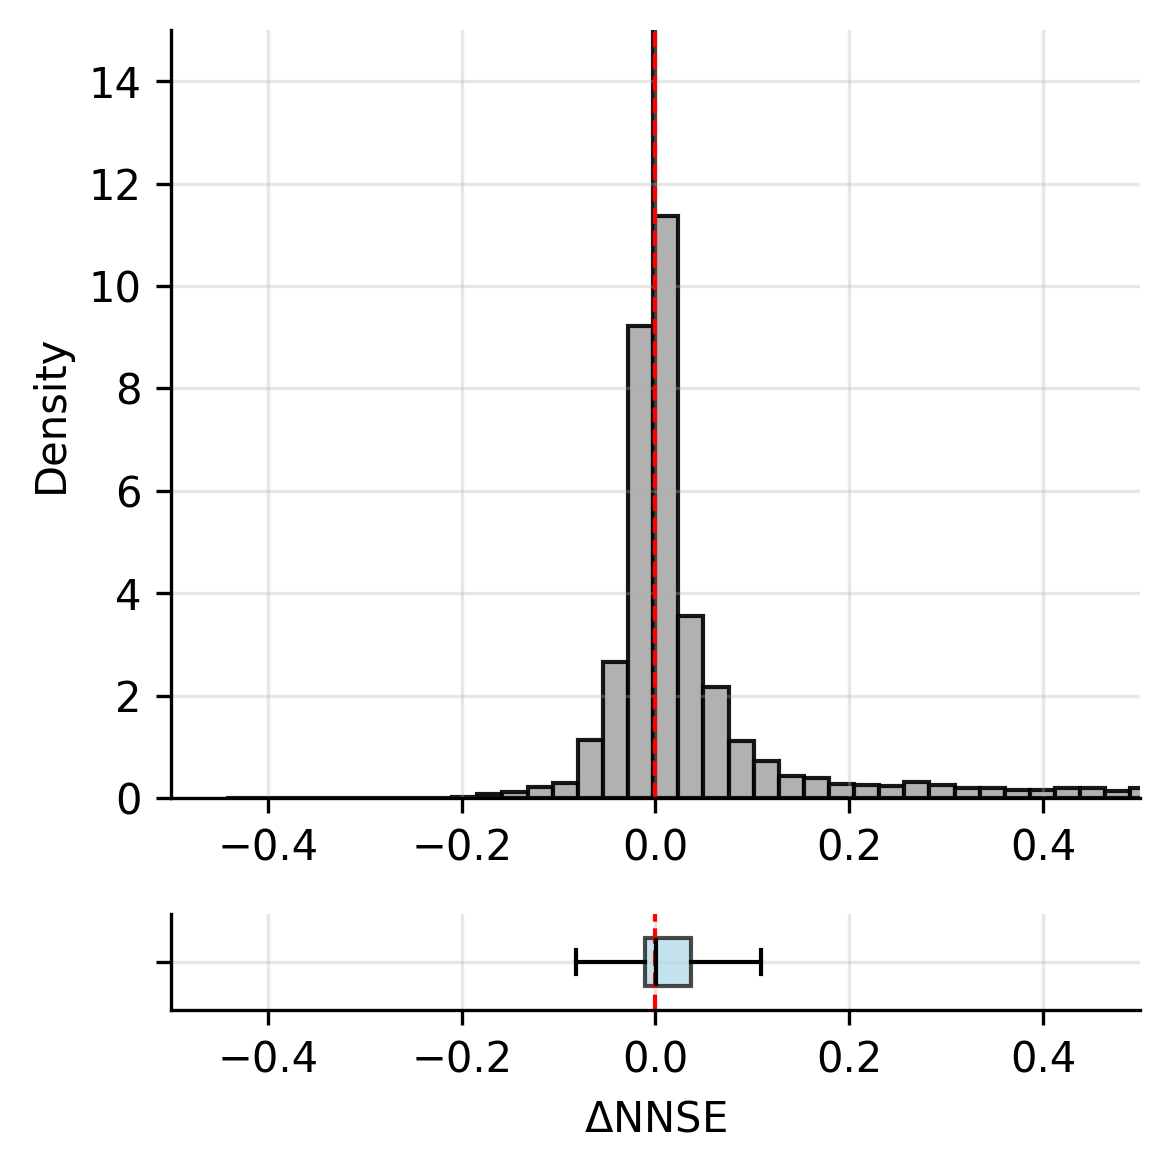

In [16]:
diff_nnse = np.array(diff_nnse)
diff_nnse_cleaned = diff_nnse[~np.isnan(diff_nnse)] 
bin_edges = np.histogram_bin_edges(diff_nnse_cleaned, bins=45)
bin_edges = np.unique(np.concatenate((bin_edges, [0])))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4), gridspec_kw={'height_ratios': [2, 0.25]}, dpi = 300)

plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0) 

ax1.hist(diff_nnse_cleaned, bins=bin_edges, alpha=0.9, edgecolor='k', color='darkgrey', density=True)
ax1.set_ylabel('Density')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 15)
ax1.set_xlim(-0.5, 0.5)

bp = ax2.boxplot(diff_nnse_cleaned, patch_artist=True, vert=False, showfliers=False, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('black')
bp['medians'][0].set_linewidth(1)

ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel(r'$\Delta \mathrm{NNSE}$')
ax2.set_yticklabels([''])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3)
ax2.set_xlim(ax1.get_xlim())

plt.tight_layout()
plt.show()

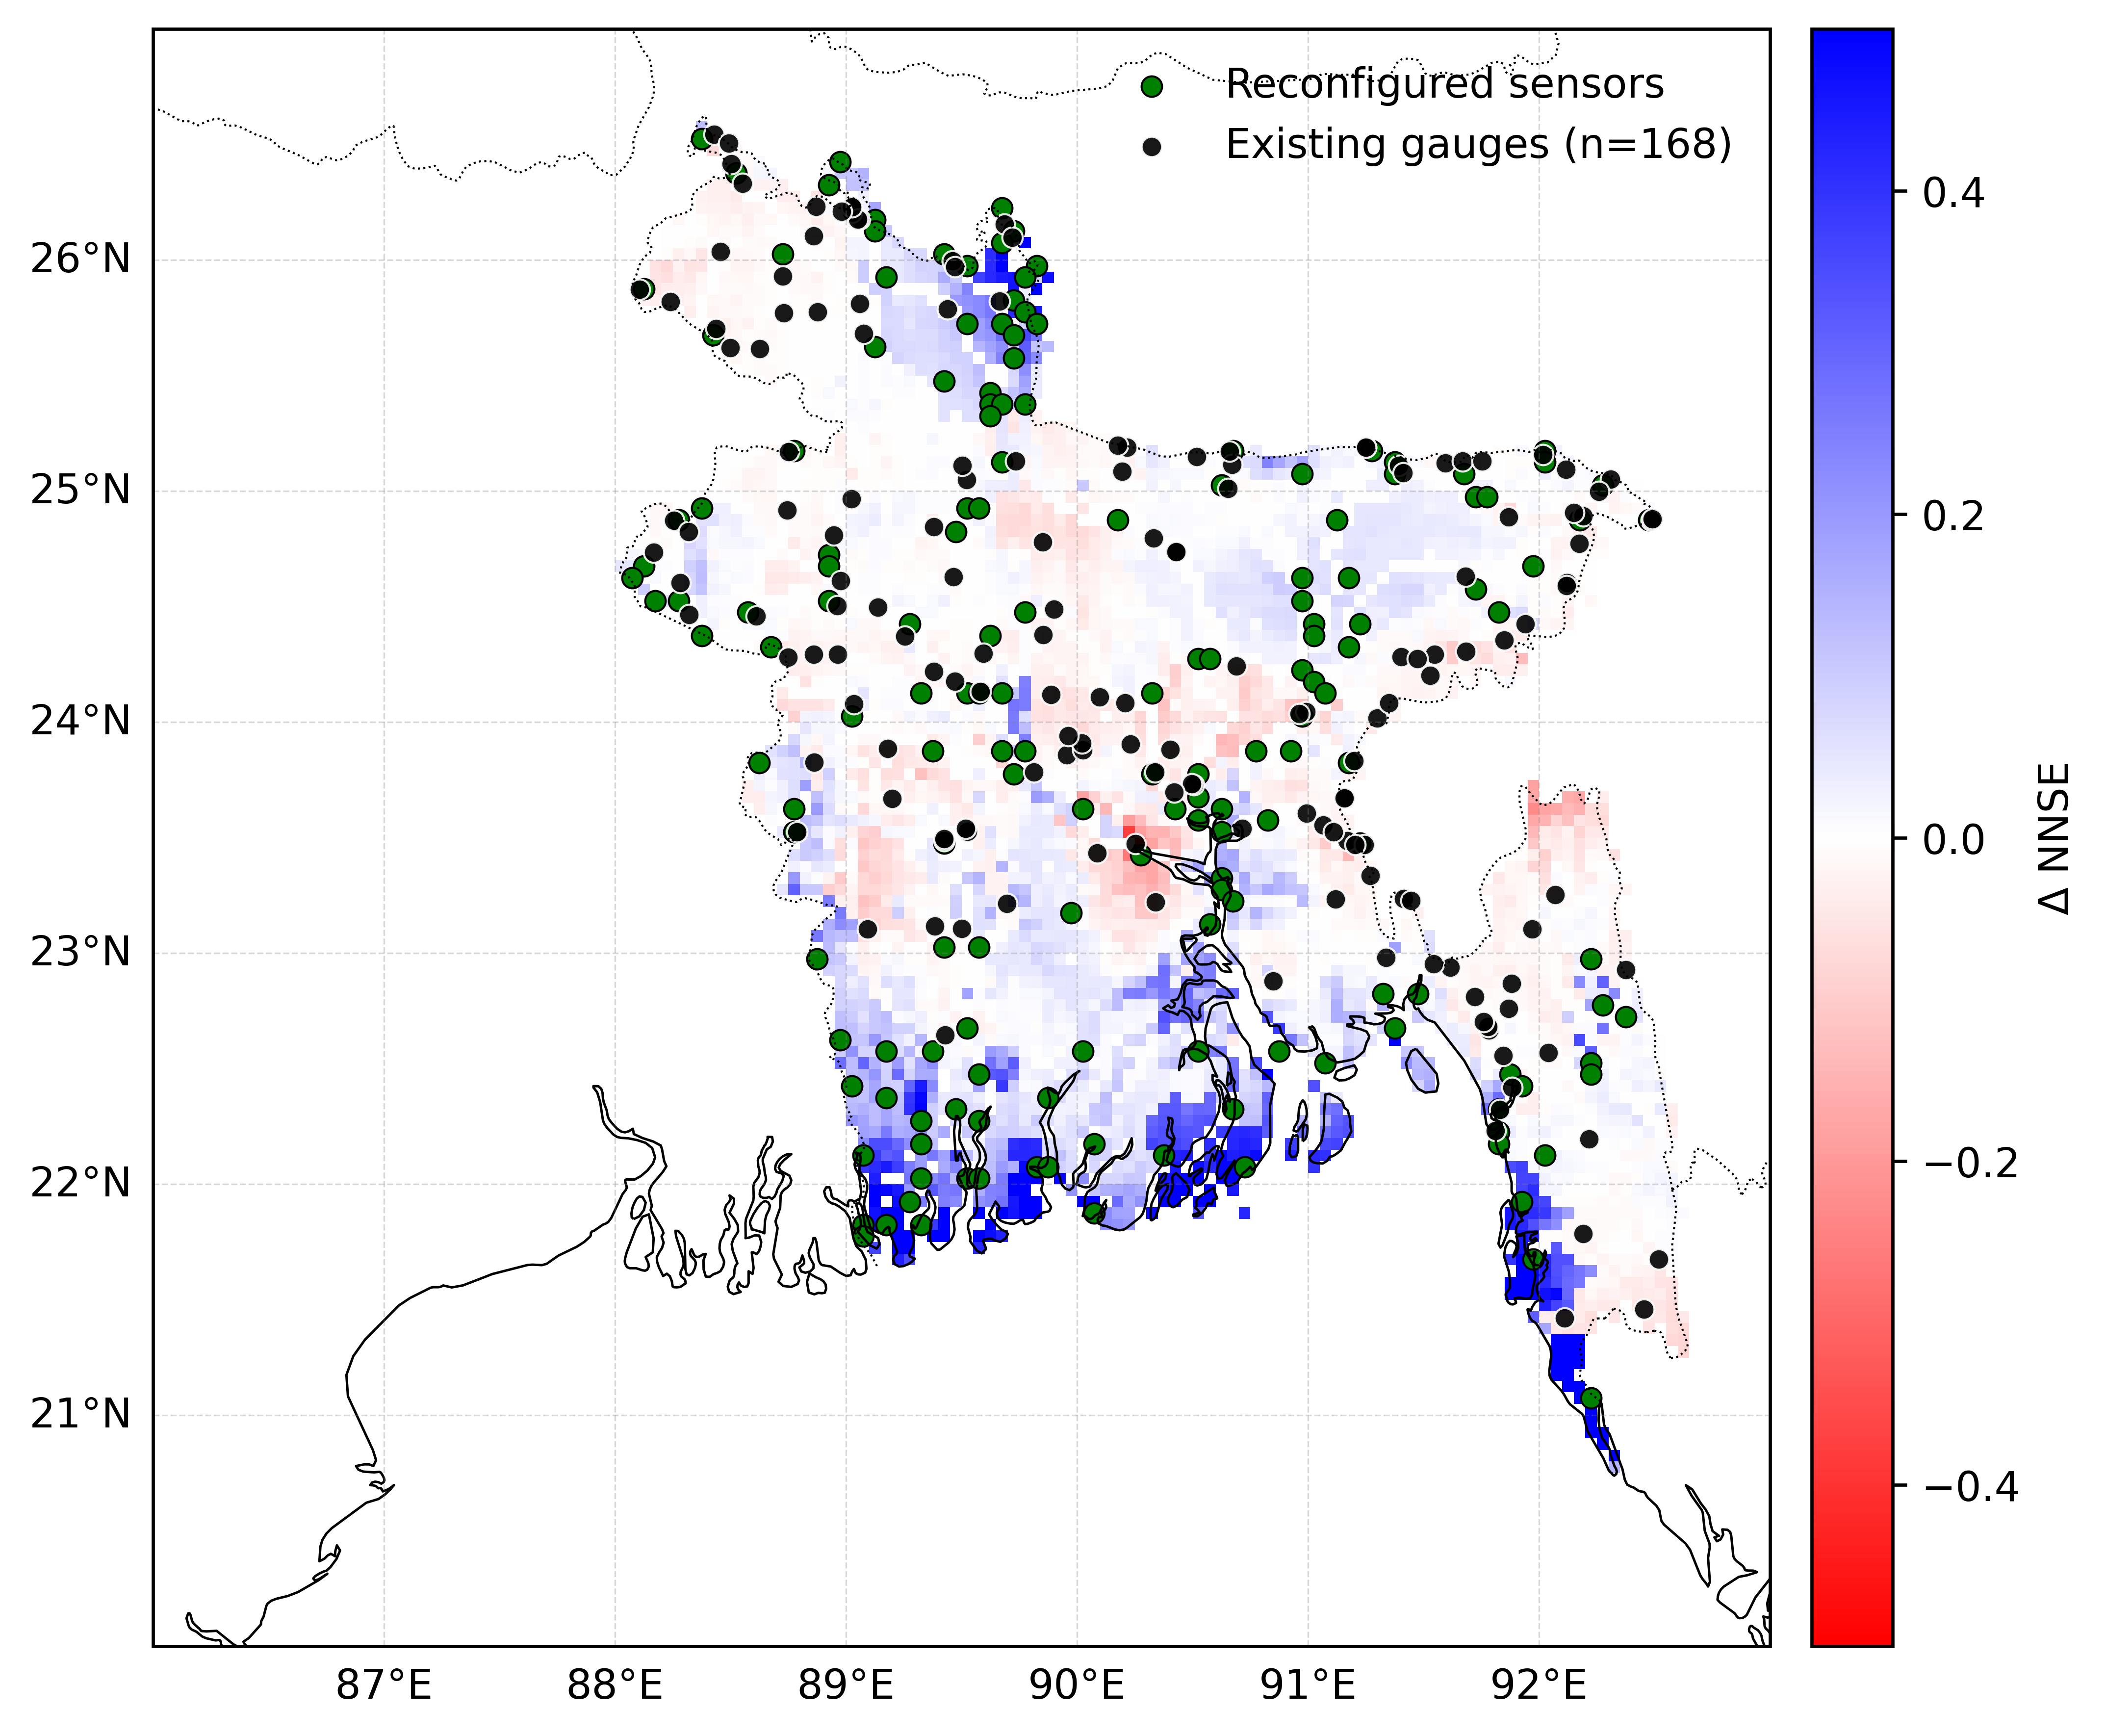

In [17]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

diff_nnse_spat = create_diff_nnse_map(
    diff_nnse,
    dis24_da
)

sel_lat = selected_sensors.lat.values
sel_lon = selected_sensors.lon.values
gauge_lat = gauge_gdf_matched.gauge_lat.values
gauge_lon = gauge_gdf_matched.gauge_lon.values

valid_vals = diff_nnse_spat.values[np.isfinite(diff_nnse_spat.values)]
vmax = np.abs(valid_vals).max() if valid_vals.size else 1
norm = TwoSlopeNorm(vmin=-0.5, vcenter=0, vmax=0.5)
cmap = plt.colormaps["bwr_r"]

plt.figure(figsize=(8, 6), dpi=600)
ax = plt.axes(projection=ccrs.PlateCarree())

plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0) 

im = ax.pcolormesh(
    diff_nnse_spat.longitude,
    diff_nnse_spat.latitude,
    diff_nnse_spat,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.scatter(
    sel_lon, sel_lat,
    marker="o", color="green", s=25, edgecolors="k", linewidth=0.5,
    label="Reconfigured sensors", transform=ccrs.PlateCarree(),
)
ax.scatter(
    gauge_lon, gauge_lat,
    marker="o", color="k", edgecolors="white", linewidth=0.5,
    s=25, alpha=0.9, label=f"Existing gauges (n={len(gauge_lat)})",
    transform=ccrs.PlateCarree(),
)

ax.set_extent([86, 93, 20, 27], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=":")

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.3, ls="--")
gl.top_labels = False    
gl.bottom_labels = True 
gl.left_labels = True    
gl.right_labels = False 

cbar = plt.colorbar(im, fraction=0.04, pad=0.02)
cbar.set_label("Δ NNSE")
ax.legend(loc="upper right", frameon=False, fontsize=10)

plt.tight_layout()
plt.show()
